In [1]:
import os
import pandas as pd
from supabase import create_client
from dotenv import load_dotenv
import matplotlib.pyplot as plt


In [2]:
from supabase import create_client
import pandas as pd,os
from dotenv import load_dotenv
load_dotenv()
supabase  = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))
data = supabase.table("telco_customer_data").select("*").execute()
df = pd.DataFrame(data.data)
df.head()

,id,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,monthly_charge_segment,has_internet_service,is_multi_line_user,contract_type_code
0,20830,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,No,New,Low,1,0,0
1,20831,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,No,Regular,Medium,1,0,1
2,20832,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,Yes,New,Medium,1,0,0
3,20833,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,No,Loyal,Medium,1,0,1
4,20834,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,Yes,New,High,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1000 non-null   int64  
 1   SeniorCitizen           1000 non-null   int64  
 2   Partner                 1000 non-null   object 
 3   Dependents              1000 non-null   object 
 4   tenure                  1000 non-null   int64  
 5   PhoneService            1000 non-null   object 
 6   MultipleLines           1000 non-null   object 
 7   InternetService         1000 non-null   object 
 8   OnlineSecurity          1000 non-null   object 
 9   OnlineBackup            1000 non-null   object 
 10  DeviceProtection        1000 non-null   object 
 11  TechSupport             1000 non-null   object 
 12  StreamingTV             1000 non-null   object 
 13  StreamingMovies         1000 non-null   object 
 14  Contract                1000 non-null   o

In [4]:
df.isnull().sum()

id                        0
SeniorCitizen             0
Partner                   0
Dependents                0
tenure                    0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
OnlineBackup              0
DeviceProtection          0
TechSupport               0
StreamingTV               0
StreamingMovies           0
Contract                  0
PaperlessBilling          0
PaymentMethod             0
MonthlyCharges            0
TotalCharges              0
Churn                     0
tenure_group              0
monthly_charge_segment    0
has_internet_service      0
is_multi_line_user        0
contract_type_code        0
dtype: int64

In [5]:
total = len(df)
churn_counts = df["Churn"].value_counts(dropna=False)
churn_yes = churn_counts.get("Yes", 0)
churn_pct = (churn_yes / total * 100) if total > 0 else 0

print("Total customers:", total)
print("Churn counts:\n", churn_counts)
print(f"Churn % (Yes): {churn_pct:.2f}%")


Total customers: 1000
Churn counts:
 Churn
No     745
Yes    255
Name: count, dtype: int64
Churn % (Yes): 25.50%


Step 3 — Average Monthly Charges per Contract

In [6]:
avg_by_contract = df.groupby("Contract")["MonthlyCharges"].mean().round(2)
avg_by_contract


Contract
Month-to-month    67.31
One year          68.18
Two year          63.12
Name: MonthlyCharges, dtype: float64

Step 4 — Tenure Group Counts (New / Regular / Loyal / Champion)

In [7]:
tenure_counts = df["tenure_group"].value_counts()
tenure_counts


tenure_group
New         320
Regular     268
Champion    210
Loyal       202
Name: count, dtype: int64

Step 5 — Internet Service Distribution

In [8]:
internet_dist = df["InternetService"].value_counts()
internet_dist


InternetService
Fiber optic    468
DSL            328
No             204
Name: count, dtype: int64

Step 6 — Pivot: Churn vs Tenure Group

In [9]:
pivot = pd.crosstab(df["tenure_group"], df["Churn"])
pivot


Churn,No,Yes
tenure_group,,
Champion,197,13
Loyal,169,33
New,167,153
Regular,212,56


Step 7 — Optional Visuals

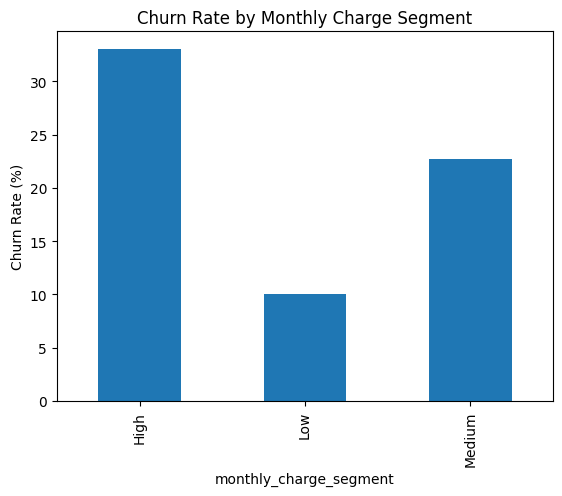

In [ ]:
# Churn rate by Monthly Charge Segment
churn_by_charge = (
    df.groupby("monthly_charge_segment")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

churn_by_charge.plot(kind="bar")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Monthly Charge Segment")
plt.show()


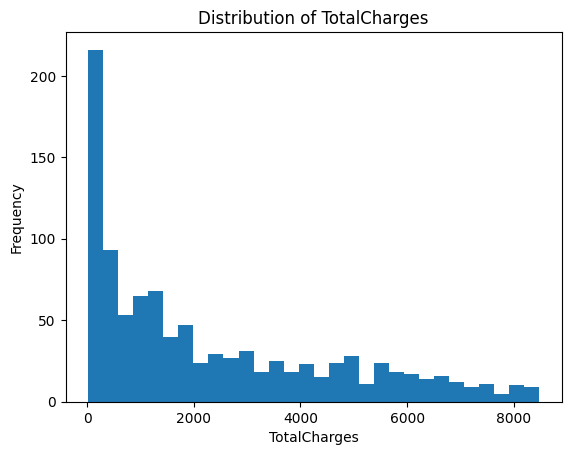

In [12]:
# Histogram of TotalCharges
plt.hist(df["TotalCharges"], bins=30)
plt.xlabel("TotalCharges")
plt.ylabel("Frequency")
plt.title("Distribution of TotalCharges")
plt.show()

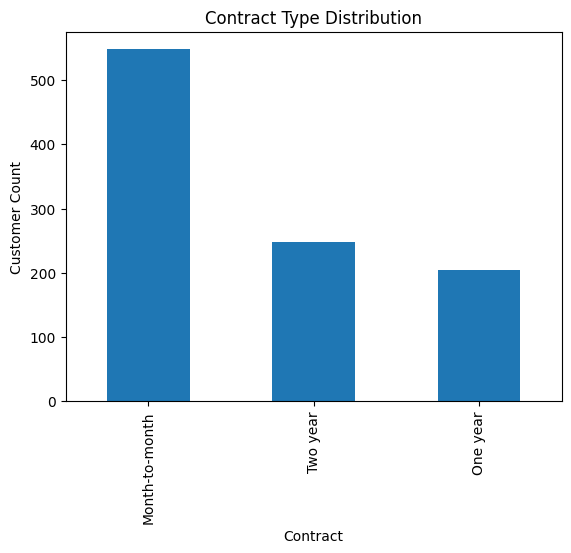

In [13]:
# Bar plot of Contract types
df["Contract"].value_counts().plot(kind="bar")
plt.ylabel("Customer Count")
plt.title("Contract Type Distribution")
plt.show()

Save analysis summary CSV

In [ ]:
analysis_summary = {
    "total_customers": total,
    "churn_yes_count": churn_yes,
    "churn_percentage": round(churn_pct, 2),
    "avg_monthly_by_contract": avg_by_contract.to_dict(),
    "tenure_group_counts": tenure_counts.to_dict(),     
    "internet_service_distribution": internet_dist.to_dict(),
    "churn_by_monthly_charge_segment": churn_by_charge.round(2).to_dict(),
}

summary_df = pd.DataFrame([analysis_summary])
summary_df


,total_customers,churn_yes_count,churn_percentage,avg_monthly_by_contract,tenure_group_counts,internet_service_distribution,churn_by_monthly_charge_segment
0,1000,255,25.5,"{'Month-to-month': 67.31, 'One year': 68.18, '...","{'New': 320, 'Regular': 268, 'Champion': 210, ...","{'Fiber optic': 468, 'DSL': 328, 'No': 204}","{'High': 33.02, 'Low': 10.05, 'Medium': 22.73}"


In [17]:
# Save locally in Colab
summary_df.to_csv("analysis_summary.csv", index=False)
